<a href="https://colab.research.google.com/github/Zetastico/Inteligencia-Artificial-I/blob/main/Lab%205%20ClasificacionBinariaPytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
path = '/content/drive/MyDrive/IA Dataset/Dataset_Regresion_Log_50k.csv'
df = pd.read_csv(path)

df_red = df.head(20000).copy()

X_raw = df_red.iloc[:, :20].values

y = df_red['label'].apply(lambda x: 1 if 'DDoS' in str(x) else 0).values

# test
X_test_raw = df.iloc[20000:24000, :20].values
y_test = df.iloc[20000:24000]['label'].apply(lambda x: 1 if 'DDoS' in str(x) else 0).values

In [38]:
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)

X_std[X_std == 0] = 1

X_raw = np.nan_to_num(X_raw)
X_test_raw = np.nan_to_num(X_test_raw)

X_train = (X_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

In [39]:
class DatasetClasificacion(torch.utils.data.Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1,1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [40]:
train_dataset = DatasetClasificacion(X_train, y)
test_dataset = DatasetClasificacion(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [41]:
model = torch.nn.Sequential(
    torch.nn.Linear(20, 64),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(64, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 1)
)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [42]:
epochs = 100
best_loss = float("inf")

history_loss = []

for epoch in range(epochs):
    model.train()
    epoch_loss = []

    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss.append(loss.item())

    avg_loss = np.mean(epoch_loss)
    history_loss.append(avg_loss)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    avg_loss = np.mean(epoch_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "mejor_modelo_clasificacion.pt")
        print("Mejor modelo guardado")

Epoch 1, Loss: 0.4311
Mejor modelo guardado
Epoch 2, Loss: 0.3616
Mejor modelo guardado
Epoch 3, Loss: 0.3417
Mejor modelo guardado
Epoch 4, Loss: 0.3306
Mejor modelo guardado
Epoch 5, Loss: 0.3226
Mejor modelo guardado
Epoch 6, Loss: 0.3154
Mejor modelo guardado
Epoch 7, Loss: 0.3134
Mejor modelo guardado
Epoch 8, Loss: 0.3065
Mejor modelo guardado
Epoch 9, Loss: 0.3051
Mejor modelo guardado
Epoch 10, Loss: 0.3030
Mejor modelo guardado
Epoch 11, Loss: 0.2970
Mejor modelo guardado
Epoch 12, Loss: 0.2962
Mejor modelo guardado
Epoch 13, Loss: 0.2920
Mejor modelo guardado
Epoch 14, Loss: 0.2899
Mejor modelo guardado
Epoch 15, Loss: 0.2876
Mejor modelo guardado
Epoch 16, Loss: 0.2852
Mejor modelo guardado
Epoch 17, Loss: 0.2835
Mejor modelo guardado
Epoch 18, Loss: 0.2793
Mejor modelo guardado
Epoch 19, Loss: 0.2778
Mejor modelo guardado
Epoch 20, Loss: 0.2760
Mejor modelo guardado
Epoch 21, Loss: 0.2744
Mejor modelo guardado
Epoch 22, Loss: 0.2746
Epoch 23, Loss: 0.2721
Mejor modelo guard

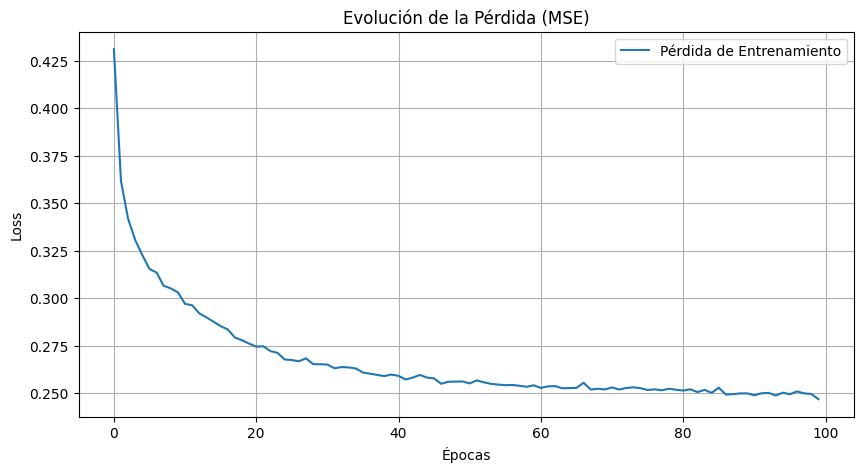

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(history_loss, label='Pérdida de Entrenamiento')
plt.title('Evolución de la Pérdida (MSE)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
model.load_state_dict(torch.load("mejor_modelo_clasificacion.pt"))
model.eval()

Sequential(
  (0): Linear(in_features=20, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Linear(in_features=32, out_features=1, bias=True)
)

In [45]:
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)

        # convertir probabilidad → clase (0 o 1
        predicted = (torch.sigmoid(y_pred) > 0.3).float()

        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
print("Accuracy:", accuracy)

Accuracy: 0.88475


In [46]:
y_preds = []
y_reales = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        pred = model(X_batch)
        y_preds.append(pred.numpy())
        y_reales.append(y_batch.numpy())

y_preds = np.vstack(y_preds)
y_reales = np.vstack(y_reales)

In [47]:
from sklearn.metrics import confusion_matrix

y_true = []
y_pred_bin = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = (torch.sigmoid(outputs) > 0.3).int()

        y_true.extend(y_batch.numpy())
        y_pred_bin.extend(preds.numpy())

cm = confusion_matrix(y_true, y_pred_bin)
print("Matriz de confusión:\n", cm)

Matriz de confusión:
 [[ 749  413]
 [  48 2790]]


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_bin))

              precision    recall  f1-score   support

         0.0       0.94      0.64      0.76      1162
         1.0       0.87      0.98      0.92      2838

    accuracy                           0.88      4000
   macro avg       0.91      0.81      0.84      4000
weighted avg       0.89      0.88      0.88      4000



In [49]:
ejemplo = torch.tensor([X_test[0]], dtype=torch.float32)

with torch.no_grad():
    pred = model(ejemplo)
    clase = 1 if torch.sigmoid(pred).item() > 0.3 else 0

print("Probabilidad:", pred.item())
print("Clase predicha:", clase)
print("Clase real:", y_test[0])

Probabilidad: 2.062873125076294
Clase predicha: 1
Clase real: 1


In [50]:
for i in range(10):
    print(f"Real: {y_reales[i][0]:.2f} | Pred: {torch.sigmoid(torch.tensor(y_preds[i][0])).item():.2f}")

Real: 1.00 | Pred: 0.89
Real: 0.00 | Pred: 0.00
Real: 1.00 | Pred: 0.77
Real: 1.00 | Pred: 1.00
Real: 1.00 | Pred: 0.90
Real: 0.00 | Pred: 0.00
Real: 0.00 | Pred: 0.05
Real: 0.00 | Pred: 0.77
Real: 1.00 | Pred: 1.00
Real: 1.00 | Pred: 1.00
